# UK Health Security Agency (UKHSA) Surveillance Data

This notebook demonstrates how to access UK public health surveillance data from the [UK Health Security Agency](https://www.gov.uk/government/collections/health-protection-data).

## Data Source
- **Provider**: UK Health Security Agency
- **Coverage**: United Kingdom (England, Wales, Scotland, Northern Ireland)
- **License**: Open Government Licence (OGL)
- **Update Frequency**: Weekly

## Available Data
- Infectious disease surveillance
- Immunization coverage
- Seasonal influenza data
- Antimicrobial resistance (AMR)
- COVID-19 metrics

In [1]:
import sys
sys.path.insert(0, '../../')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from epidatasets.sources.ukhsa import UKHSAAccessor

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Initialize accessor
ukhsa = UKHSAAccessor()

## 1. List Available Indicators

In [2]:
# Display available surveillance indicators
indicators = ukhsa.get_available_indicators()
indicators

,category,indicator,frequency,api_available
0,Infectious Diseases,COVID-19 cases,Daily,True
1,Infectious Diseases,Influenza cases,Weekly,True
2,Infectious Diseases,Measles cases,Weekly,True
3,Infectious Diseases,RSV cases,Weekly,True
4,Vaccination,Childhood coverage,Quarterly,False
5,AMR,Antimicrobial resistance,Annual,False


## 2. Data Sources

In [3]:
# Show data source URLs
sources = ukhsa.get_data_sources()
sources

,category,name,url
0,Dashboard API,UKHSA Dashboard,https://api.ukhsa-dashboard.data.gov.uk
1,Infectious Diseases,COVID-19,https://api.ukhsa-dashboard.data.gov.uk/themes...
2,Infectious Diseases,Influenza,https://api.ukhsa-dashboard.data.gov.uk/themes...
3,Infectious Diseases,Measles,https://api.ukhsa-dashboard.data.gov.uk/themes...


## 3. Infectious Disease Surveillance

In [5]:
# Get infectious disease data
measles_data = ukhsa.get_infectious_disease_data(
    disease="Measles",
    years=[2022, 2023, 2024],
    regions= ["England", "Wales", "Scotland"]
)

print(f"Retrieved {len(measles_data)} records")
measles_data.head()

Retrieved 487 records


,date,disease,region,cases,year,epiweek
0,2023-09-25,Measles,England,1.0,2023,39
1,2023-09-25,Measles,England,1.0,2023,39
2,2023-10-02,Measles,England,1.0,2023,40
3,2023-10-02,Measles,England,4.0,2023,40
4,2023-10-02,Measles,England,1.0,2023,40


In [7]:
measles_data.region.value_counts()

region
England    487
Name: count, dtype: int64

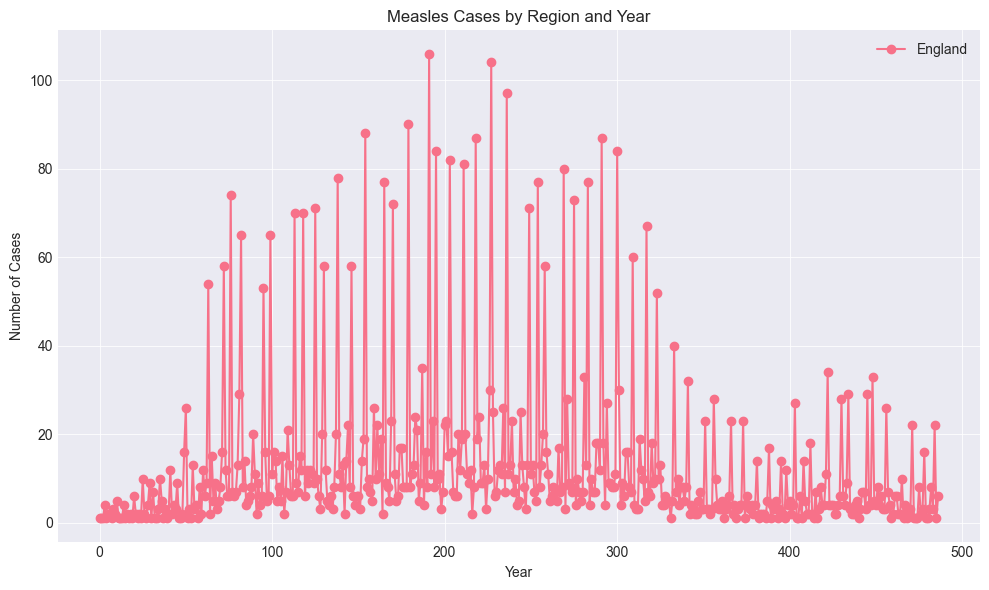

In [10]:
# Plot measles by region and year
plt.figure(figsize=(10, 6))
measles_data.date = pd.to_datetime(measles_data["date"])
measles_data.set_index('date')
for region in measles_data["region"].unique():
    region_data = measles_data[measles_data["region"] == region]
    region_data.cases.plot(marker='o',label=region)


plt.title("Measles Cases by Region and Year")
plt.xlabel("Year")
plt.ylabel("Number of Cases")
plt.legend()
plt.grid(True, alpha=0.8)
plt.tight_layout()
plt.show()

## 4. Vaccination Coverage

In [11]:
# Get MMR vaccination coverage
mmr_coverage = ukhsa.get_immunization_coverage(
    vaccines="MMR",
    years=[2019, 2020, 2021, 2022, 2023, 2024],
    age_groups=["1 year", "2 years"],
    regions=["England"]
)

print(f"Retrieved {len(mmr_coverage)} records")
mmr_coverage.head(10)

INFO:epidatasets.sources.ukhsa:Immunization coverage data is not yet available via the UKHSA Dashboard API.


Retrieved 12 records


,vaccine,year,region,age_group,coverage_percent,target,data_source,note
0,MMR,2019,England,1 year,None,95.0,UKHSA,Immunization coverage not yet available via Da...
1,MMR,2019,England,2 years,None,95.0,UKHSA,Immunization coverage not yet available via Da...
2,MMR,2020,England,1 year,None,95.0,UKHSA,Immunization coverage not yet available via Da...
3,MMR,2020,England,2 years,None,95.0,UKHSA,Immunization coverage not yet available via Da...
4,MMR,2021,England,1 year,None,95.0,UKHSA,Immunization coverage not yet available via Da...
5,MMR,2021,England,2 years,None,95.0,UKHSA,Immunization coverage not yet available via Da...
6,MMR,2022,England,1 year,None,95.0,UKHSA,Immunization coverage not yet available via Da...
7,MMR,2022,England,2 years,None,95.0,UKHSA,Immunization coverage not yet available via Da...
8,MMR,2023,England,1 year,None,95.0,UKHSA,Immunization coverage not yet available via Da...
9,MMR,2023,England,2 years,None,95.0,UKHSA,Immunization coverage not yet available via Da...


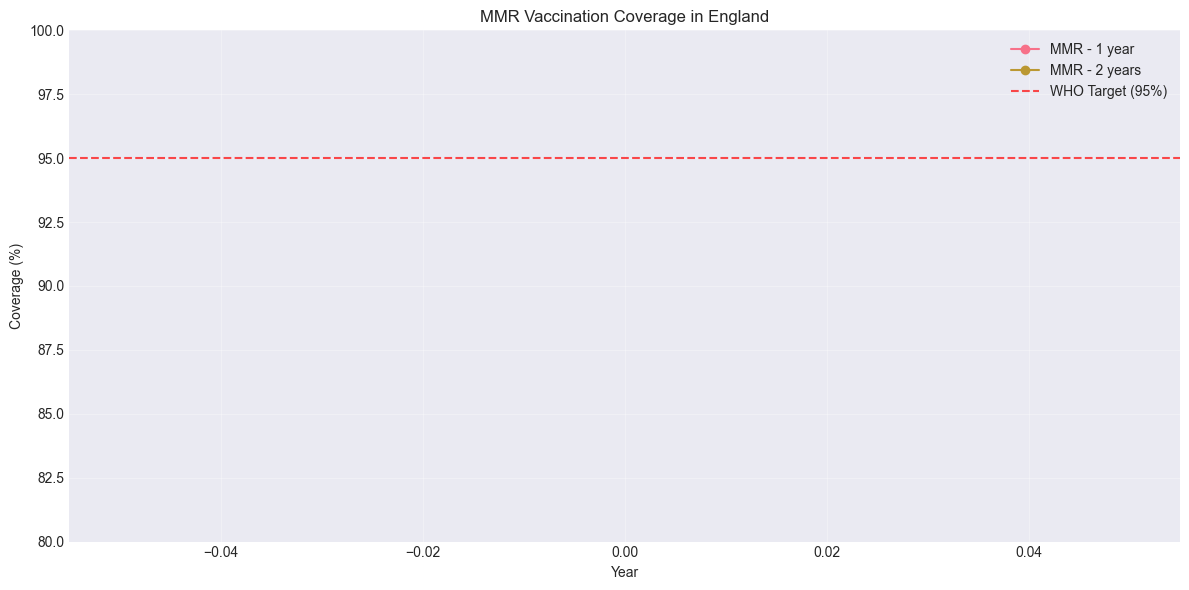

In [13]:
# Plot vaccination coverage over time
plt.figure(figsize=(12, 6))

for age in mmr_coverage["age_group"].unique():
    age_data = mmr_coverage[mmr_coverage["age_group"] == age]
    plt.plot(age_data["year"], age_data["coverage_percent"], 
             marker="o", label=f"MMR - {age}")

# WHO target line
plt.axhline(y=95, color="r", linestyle="--", alpha=0.7, label="WHO Target (95%)")

plt.title("MMR Vaccination Coverage in England")
plt.xlabel("Year")
plt.ylabel("Coverage (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(80, 100)
plt.tight_layout()
plt.show()

## 5. Seasonal Influenza

In [14]:
# Get influenza surveillance data
flu_data = ukhsa.get_seasonal_influenza_data(
    seasons=["2022/23", "2023/24"],
    regions=["England"],
    metrics=["influenza_like_illness_rate", "hospitalizations"]
)

print(f"Retrieved {len(flu_data)} records")
flu_data.head()

Retrieved 1192 records


,date,disease,region,cases,year,epiweek
0,2022-01-03,Influenza,England,0.21,2022,1
1,2022-01-03,Influenza,England,0.48,2022,1
2,2022-01-03,Influenza,England,0.58,2022,1
3,2022-01-03,Influenza,England,1.56,2022,1
4,2022-01-03,Influenza,England,1.14,2022,1


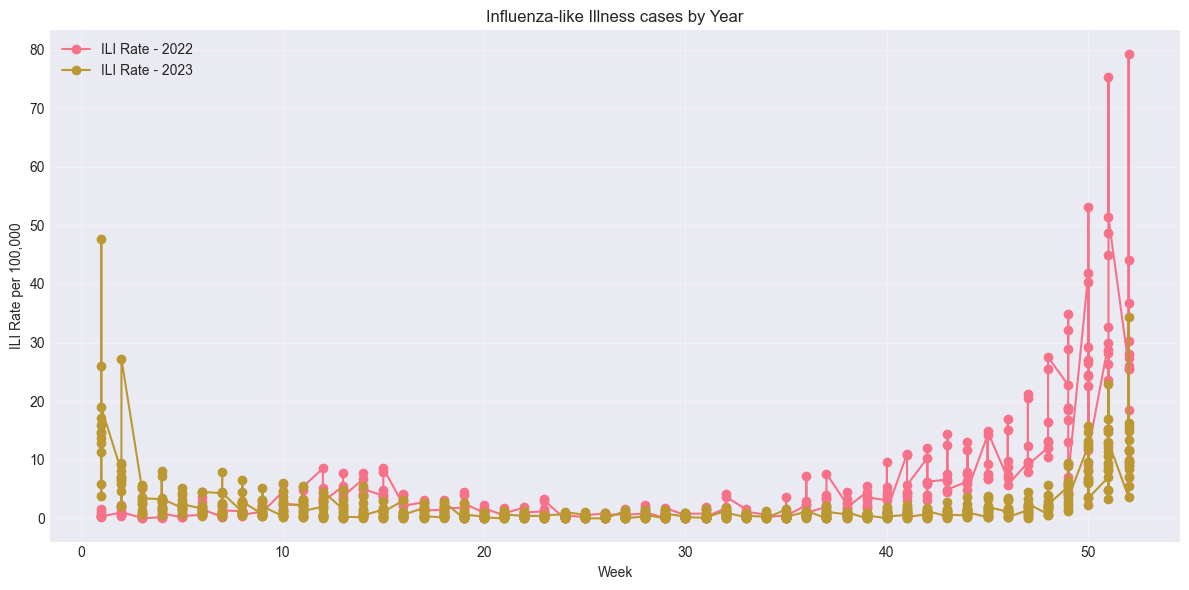

In [18]:
# Compare influenza seasons
plt.figure(figsize=(12, 6))

for season in flu_data["year"].unique():
    season_data = flu_data[flu_data["year"] == season]

    if not season_data.empty:
        plt.plot(season_data['epiweek'], season_data["cases"],
                 marker="o", label=f"ILI Rate - {season}")

plt.title("Influenza-like Illness cases by Year")
plt.xlabel("Week")
plt.ylabel("ILI Rate per 100,000")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Antimicrobial Resistance

In [19]:
# Get AMR surveillance data
amr_data = ukhsa.get_antimicrobial_resistance_data(
    years=[2020, 2021, 2022, 2023],
    organisms=["E. coli", "MRSA", "Klebsiella"]
)

print(f"Retrieved {len(amr_data)} records")
amr_data

INFO:epidatasets.sources.ukhsa:AMR data is not yet available via the UKHSA Dashboard API.


Retrieved 12 records


,year,organism,resistance_rate,sample_size,data_source,note
0,2020,E. coli,None,None,UKHSA,AMR data not yet available via Dashboard API
1,2020,MRSA,None,None,UKHSA,AMR data not yet available via Dashboard API
2,2020,Klebsiella,None,None,UKHSA,AMR data not yet available via Dashboard API
3,2021,E. coli,None,None,UKHSA,AMR data not yet available via Dashboard API
4,2021,MRSA,None,None,UKHSA,AMR data not yet available via Dashboard API
5,2021,Klebsiella,None,None,UKHSA,AMR data not yet available via Dashboard API
6,2022,E. coli,None,None,UKHSA,AMR data not yet available via Dashboard API
7,2022,MRSA,None,None,UKHSA,AMR data not yet available via Dashboard API
8,2022,Klebsiella,None,None,UKHSA,AMR data not yet available via Dashboard API
9,2023,E. coli,None,None,UKHSA,AMR data not yet available via Dashboard API


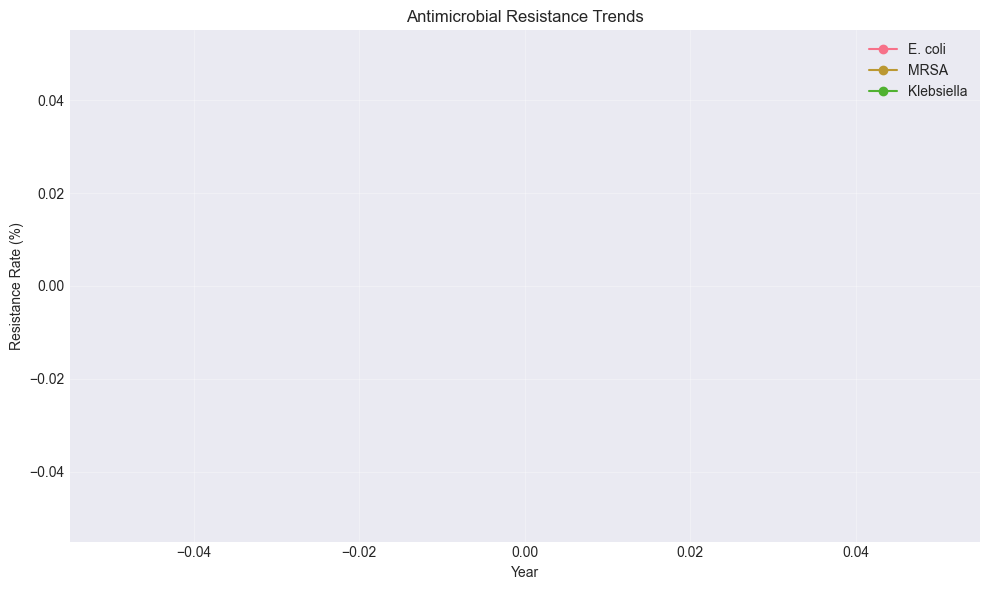

In [20]:
# Plot AMR trends
plt.figure(figsize=(10, 6))

for organism in amr_data["organism"].unique():
    org_data = amr_data[amr_data["organism"] == organism]
    plt.plot(org_data["year"], org_data["resistance_rate"], 
             marker="o", label=organism)

plt.title("Antimicrobial Resistance Trends")
plt.xlabel("Year")
plt.ylabel("Resistance Rate (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. COVID-19 Metrics

In [21]:
# Get COVID-19 data
from datetime import datetime, timedelta

end_date = datetime.now().strftime("%Y-%m-%d")
start_date = (datetime.now() - timedelta(days=90)).strftime("%Y-%m-%d")

covid_data = ukhsa.get_covid19_metrics(
    metrics=["cases", "hospitalizations", "deaths"],
    date_range=(start_date, end_date),
    regions=["England", "Wales", "Scotland"]
)

print(f"Retrieved {len(covid_data)} records")
covid_data.head()

Retrieved 84 records


,date,disease,region,cases,year,epiweek
0,2025-12-25,COVID-19,England,65.0,2025,52
1,2025-12-26,COVID-19,England,75.0,2025,52
2,2025-12-27,COVID-19,England,74.0,2025,52
3,2025-12-28,COVID-19,England,86.0,2025,52
4,2025-12-29,COVID-19,England,112.0,2025,1


## Summary

This notebook demonstrated how to:
1. List available UKHSA surveillance indicators
2. Access infectious disease surveillance data
3. Analyze vaccination coverage trends
4. Work with seasonal influenza data
5. Examine antimicrobial resistance patterns
6. Retrieve COVID-19 metrics

For more information, visit: https://www.gov.uk/government/collections/health-protection-data